# EfficientNet-B3: T2-Only vs Multimodal Evaluation
**Comparison:** EfficientNet-B3 (T2 only) vs EfficientNet-B3 (T2 + ADC + TraceW + CalcBval)  
**Task:** Binary PIRADS classification (≥3 = clinically significant cancer)  
**Author:** Akshaya Ganesh

In [1]:
# Cell 1 — Mount Drive and extract DICOMs
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os
import tarfile

DATA_DIR  = '/content/drive/MyDrive/Colab Notebooks'
DICOM_DIR = '/content/DICOMS'
os.makedirs(DICOM_DIR, exist_ok=True)

print('Extracting DICOMs...')
with tarfile.open(f'{DATA_DIR}/fastmri_prostate_DICOMS_IDS_001_312.tar', 'r') as tar:
    tar.extractall(DICOM_DIR)

DICOM_DIR = '/content/DICOMS/DICOMS'
print(f'Patients: {len(os.listdir(DICOM_DIR))}')

Mounted at /content/drive
Extracting DICOMs...


/tmp/ipykernel_5888/2693115195.py:14: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(DICOM_DIR)


Patients: 312


In [2]:
# Cell 2 — Installs
!pip install pydicom -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 26.1 MB/s eta 0:00:00


In [3]:
# Cell 3 — Imports
import os
import json
import numpy as np
import pandas as pd
import tarfile
import pydicom
import torch
import torch.nn as nn
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    roc_auc_score, roc_curve, classification_report,
    confusion_matrix, precision_recall_curve, average_precision_score
)
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11
sns.set_style('whitegrid')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


In [4]:
# Cell 4 — Load labels and test split
labels_tar = f'{DATA_DIR}/labels.tar'
with tarfile.open(labels_tar, 'r') as tar:
    f = tar.extractfile('labels/t2_slice_level_labels.csv')
    t2_labels = pd.read_csv(f)
    f = tar.extractfile('labels/volume_exam_labels.csv')
    volume_labels = pd.read_csv(f)

volume_labels['binary_label'] = (volume_labels['t2_volume_level'] >= 3).astype(int)
patient_split = t2_labels.drop_duplicates('fastmri_pt_id')[['fastmri_pt_id', 'data_split']]
df = patient_split.merge(
    volume_labels[['fastmri_pt_id', 'binary_label', 't2_volume_level']],
    on='fastmri_pt_id'
)

invalid_ids = [115, 258]
test_df = df[df['data_split'] == 'test'].reset_index(drop=True)
test_df = test_df[~test_df['fastmri_pt_id'].isin(invalid_ids)].reset_index(drop=True)

# For multimodal — filter to patients with all sequences
SEQUENCES = ['AX_T2', 'AX_DIFFUSION_ADC', 'AX_DIFFUSION_TRACEW', 'AX_DIFFUSION_CALC_BVAL']
missing = set()
for pt_id in test_df['fastmri_pt_id']:
    pt_path = os.path.join(DICOM_DIR, str(pt_id).zfill(3))
    for seq in SEQUENCES:
        seq_path = os.path.join(pt_path, seq)
        if not os.path.exists(seq_path) or len(os.listdir(seq_path)) == 0:
            missing.add(pt_id)

test_df_multimodal = test_df[~test_df['fastmri_pt_id'].isin(missing)].reset_index(drop=True)

print(f'T2-only test patients:    {len(test_df)}')
print(f'Multimodal test patients: {len(test_df_multimodal)}')
print(f'T2 labels:    {test_df.binary_label.value_counts().to_dict()}')
print(f'Multimodal labels: {test_df_multimodal.binary_label.value_counts().to_dict()}')

T2-only test patients:    46
Multimodal test patients: 45
T2 labels:    {0: 26, 1: 20}
Multimodal labels: {0: 26, 1: 19}


In [5]:
# Cell 5 — Dataset classes

# T2-only 3x3 grid dataset
class ProstateT2Dataset(Dataset):
    def __init__(self, df, dicom_dir):
        self.df = df.reset_index(drop=True)
        self.dicom_dir = dicom_dir
        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row    = self.df.iloc[idx]
        pt_id  = str(row.fastmri_pt_id).zfill(3)
        t2_path = os.path.join(self.dicom_dir, pt_id, 'AX_T2')
        slices = []
        for fname in os.listdir(t2_path):
            if fname.endswith('.dcm'):
                ds = pydicom.dcmread(os.path.join(t2_path, fname))
                slices.append((int(ds.InstanceNumber), ds.pixel_array.astype(np.float32)))
        slices.sort(key=lambda x: x[0])
        volume = np.stack([s[1] for s in slices])
        volume = (volume - volume.min()) / (volume.max() - volume.min() + 1e-8)
        mid      = volume.shape[0] // 2
        selected = volume[mid-4:mid+5]
        rows = []
        for i in range(3):
            row_img = np.concatenate([selected[i*3], selected[i*3+1], selected[i*3+2]], axis=1)
            rows.append(row_img)
        grid  = np.concatenate(rows, axis=0)
        img   = Image.fromarray((grid * 255).astype(np.uint8)).convert('RGB')
        img   = self.transform(img)
        label = torch.tensor(row.binary_label, dtype=torch.float32)
        return img, label


# Multimodal 4-channel dataset
def load_sequence_grid(pt_path, seq_name, target_size=(160, 160)):
    seq_path = os.path.join(pt_path, seq_name)
    slices   = []
    for fname in os.listdir(seq_path):
        if fname.endswith('.dcm'):
            ds  = pydicom.dcmread(os.path.join(seq_path, fname))
            arr = ds.pixel_array.astype(np.float32)
            img = Image.fromarray(arr).resize(target_size, Image.BILINEAR)
            arr = np.array(img)
            slices.append((int(ds.InstanceNumber), arr))
    slices.sort(key=lambda x: x[0])
    volume = np.stack([s[1] for s in slices])
    volume = (volume - volume.min()) / (volume.max() - volume.min() + 1e-8)
    mid      = volume.shape[0] // 2
    selected = volume[mid-4:mid+5]
    rows = []
    for i in range(3):
        row_img = np.concatenate([selected[i*3], selected[i*3+1], selected[i*3+2]], axis=1)
        rows.append(row_img)
    return np.concatenate(rows, axis=0)


class ProstateMultimodalDataset(Dataset):
    def __init__(self, df, dicom_dir):
        self.df        = df.reset_index(drop=True)
        self.dicom_dir = dicom_dir
        self.spatial_transform = transforms.Resize((224, 224))
        self.to_tensor = transforms.ToTensor()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row     = self.df.iloc[idx]
        pt_id   = str(row.fastmri_pt_id).zfill(3)
        pt_path = os.path.join(self.dicom_dir, pt_id)
        channel_tensors = []
        for seq in SEQUENCES:
            grid = load_sequence_grid(pt_path, seq)
            img  = Image.fromarray((grid * 255).astype(np.uint8))
            img  = self.spatial_transform(img)
            img  = self.to_tensor(img)
            channel_tensors.append(img)
        combined = torch.cat(channel_tensors, dim=0)  # (4, 224, 224)
        mean = torch.tensor([0.485, 0.456, 0.406, 0.456]).view(4, 1, 1)
        std  = torch.tensor([0.229, 0.224, 0.225, 0.226]).view(4, 1, 1)
        combined = (combined - mean) / std
        label = torch.tensor(row.binary_label, dtype=torch.float32)
        return combined, label

In [6]:
# Cell 6 — Model architectures

# T2-only EfficientNet-B3 (3 channels)
def get_efficientnet_t2(dropout=0.5):
    model = models.efficientnet_b3(weights=None)
    for i, block in enumerate(model.features):
        if i < 4:
            for param in block.parameters():
                param.requires_grad = False
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=dropout),
        nn.Linear(in_features, 1)
    )
    return model


# Multimodal EfficientNet-B3 (4 channels)
def get_efficientnet_multimodal(dropout=0.5):
    model = models.efficientnet_b3(weights=None)
    original_conv = model.features[0][0]
    new_conv = nn.Conv2d(
        in_channels=4,
        out_channels=original_conv.out_channels,
        kernel_size=original_conv.kernel_size,
        stride=original_conv.stride,
        padding=original_conv.padding,
        bias=original_conv.bias is not None
    )
    model.features[0][0] = new_conv
    for i, block in enumerate(model.features):
        if i < 4:
            for param in block.parameters():
                param.requires_grad = False
    for param in model.features[0].parameters():
        param.requires_grad = True
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=dropout),
        nn.Linear(in_features, 1)
    )
    return model


print('Model architectures defined.')

Model architectures defined.


In [7]:
# Cell 7 — Load results JSON files
results = {}
for name, path in [
    ('EfficientNet T2-only',    f'{DATA_DIR}/efficientnet_results.json'),
    ('EfficientNet Multimodal', f'{DATA_DIR}/efficientnet_multimodal_results.json'),
]:
    if os.path.exists(path):
        with open(path) as f:
            results[name] = json.load(f)
        print(f'{name}: Val AUC={results[name]["best_val_auc"]:.4f}, Test AUC={results[name]["test_auc"]:.4f}')
    else:
        print(f'{name}: results file not found — run the training notebook first')

EfficientNet T2-only: Val AUC=0.6813, Test AUC=0.5500
EfficientNet Multimodal: Val AUC=0.5861, Test AUC=0.6113


In [8]:
# Cell 8 — Load model weights and get predictions
def get_predictions(model, loader, device):
    model.eval()
    all_probs, all_preds, all_labels = [], [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs   = imgs.to(device)
            output = torch.sigmoid(model(imgs).squeeze(1))
            preds  = (output > 0.5).float()
            all_probs.extend(output.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_probs), np.array(all_preds), np.array(all_labels)


model_predictions = {}

# ── T2-only EfficientNet ──────────────────────────────────────────────────
t2_dropout = results.get('EfficientNet T2-only', {}).get('best_params', {}).get('dropout', 0.5)
t2_path    = f'{DATA_DIR}/best_efficientnet.pth'

if os.path.exists(t2_path):
    test_dataset_t2 = ProstateT2Dataset(test_df, DICOM_DIR)
    test_loader_t2  = DataLoader(test_dataset_t2, batch_size=16, shuffle=False, num_workers=0)
    t2_model = get_efficientnet_t2(dropout=t2_dropout).to(device)
    t2_model.load_state_dict(torch.load(t2_path, map_location=device))
    probs, preds, labels = get_predictions(t2_model, test_loader_t2, device)
    model_predictions['EfficientNet\nT2-only'] = {'probs': probs, 'preds': preds, 'labels': labels}
    print(f'T2-only loaded.    Test AUC: {roc_auc_score(labels, probs):.4f} ({len(test_df)} patients)')
else:
    print(f'T2-only weights not found at {t2_path}')

# ── Multimodal EfficientNet ───────────────────────────────────────────────
mm_dropout = results.get('EfficientNet Multimodal', {}).get('best_params', {}).get('dropout', 0.5)
mm_path    = f'{DATA_DIR}/best_efficientnet_multimodal.pth'

if os.path.exists(mm_path):
    test_dataset_mm = ProstateMultimodalDataset(test_df_multimodal, DICOM_DIR)
    test_loader_mm  = DataLoader(test_dataset_mm, batch_size=8, shuffle=False, num_workers=0)
    mm_model = get_efficientnet_multimodal(dropout=mm_dropout).to(device)
    mm_model.load_state_dict(torch.load(mm_path, map_location=device))
    probs, preds, labels = get_predictions(mm_model, test_loader_mm, device)
    model_predictions['EfficientNet\nMultimodal'] = {'probs': probs, 'preds': preds, 'labels': labels}
    print(f'Multimodal loaded. Test AUC: {roc_auc_score(labels, probs):.4f} ({len(test_df_multimodal)} patients)')
else:
    print(f'Multimodal weights not found at {mm_path} — run the multimodal training notebook first')

T2-only loaded.    Test AUC: 0.5500 (46 patients)
Multimodal loaded. Test AUC: 0.6093 (45 patients)


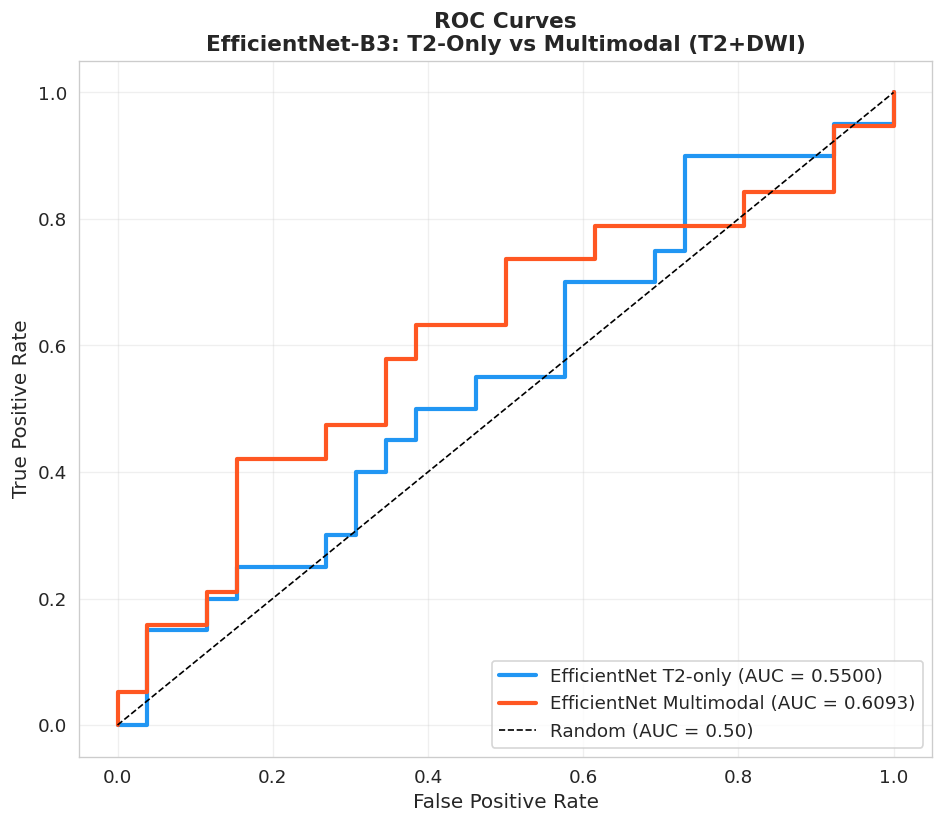

In [9]:
# Cell 9 — ROC curves side by side
colors = ['#2196F3', '#FF5722']

plt.figure(figsize=(8, 7))
for (name, data), color in zip(model_predictions.items(), colors):
    fpr, tpr, _ = roc_curve(data['labels'], data['probs'])
    auc = roc_auc_score(data['labels'], data['probs'])
    plt.plot(fpr, tpr, color=color, linewidth=2.5,
             label=f'{name.replace(chr(10), " ")} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.50)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves\nEfficientNet-B3: T2-Only vs Multimodal (T2+DWI)',
          fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/eval_eff_roc.png', bbox_inches='tight')
plt.show()

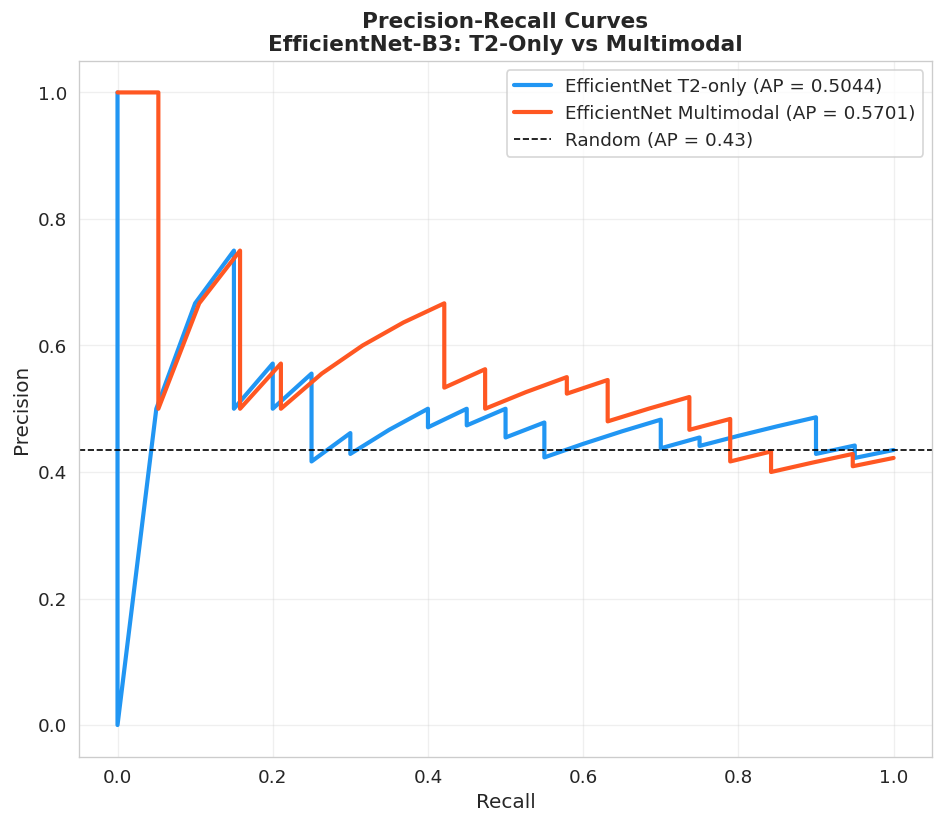

In [10]:
# Cell 10 — Precision-Recall curves
plt.figure(figsize=(8, 7))
for (name, data), color in zip(model_predictions.items(), colors):
    precision, recall, _ = precision_recall_curve(data['labels'], data['probs'])
    ap = average_precision_score(data['labels'], data['probs'])
    plt.plot(recall, precision, color=color, linewidth=2.5,
             label=f'{name.replace(chr(10), " ")} (AP = {ap:.4f})')

baseline = np.array(list(model_predictions.values())[0]['labels']).mean()
plt.axhline(y=baseline, color='k', linestyle='--', linewidth=1,
            label=f'Random (AP = {baseline:.2f})')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curves\nEfficientNet-B3: T2-Only vs Multimodal',
          fontsize=13, fontweight='bold')
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/eval_eff_pr.png', bbox_inches='tight')
plt.show()

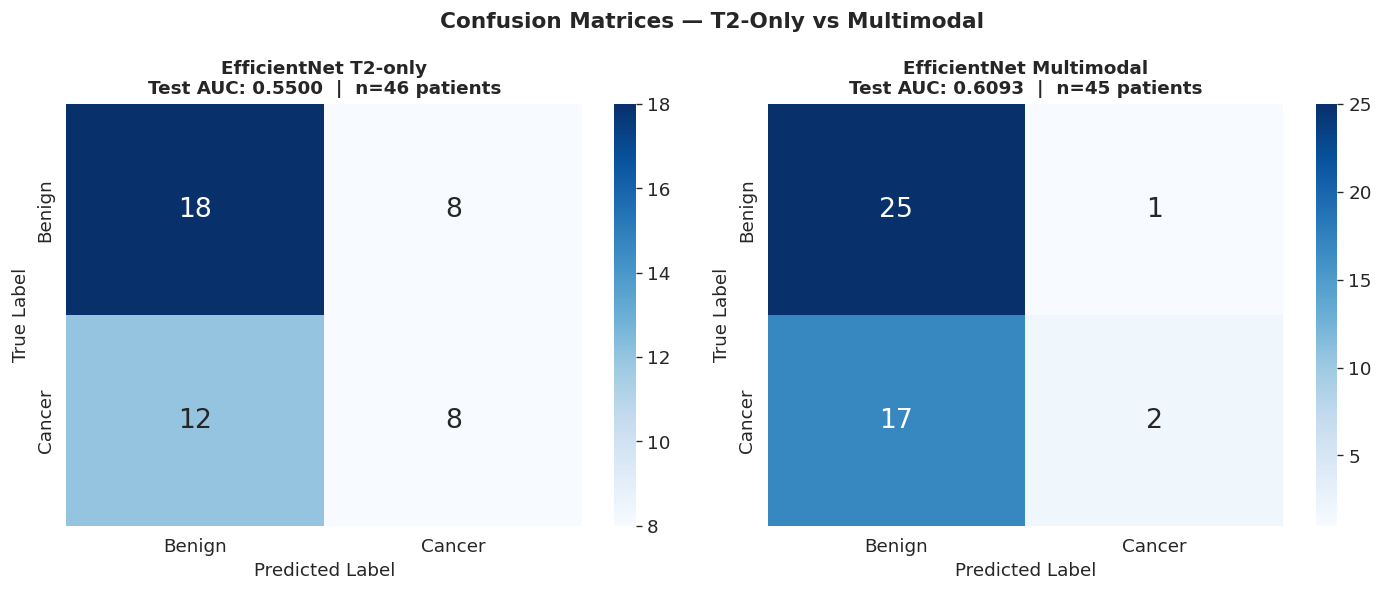

In [11]:
# Cell 11 — Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, data), color in zip(axes, model_predictions.items(), colors):
    cm  = confusion_matrix(data['labels'], data['preds'])
    auc = roc_auc_score(data['labels'], data['probs'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Benign', 'Cancer'],
                yticklabels=['Benign', 'Cancer'],
                annot_kws={'size': 16})
    ax.set_title(f'{name.replace(chr(10), " ")}\nTest AUC: {auc:.4f}  |  n={len(data["labels"])} patients',
                fontweight='bold', fontsize=11)
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.suptitle('Confusion Matrices — T2-Only vs Multimodal', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/eval_eff_cm.png', bbox_inches='tight')
plt.show()

In [12]:
# Cell 12 — Classification reports
for name, data in model_predictions.items():
    print(f'\n{"=" * 55}')
    print(f'  {name.replace(chr(10), " ")}')
    print(f'{"=" * 55}')
    print(classification_report(
        data['labels'], data['preds'],
        target_names=['Benign (PIRADS 1-2)', 'Cancer (PIRADS 3-5)'],
        digits=4
    ))
    auc = roc_auc_score(data['labels'], data['probs'])
    ap  = average_precision_score(data['labels'], data['probs'])
    print(f'  ROC AUC:           {auc:.4f}')
    print(f'  Average Precision: {ap:.4f}')


  EfficientNet T2-only
                     precision    recall  f1-score   support

Benign (PIRADS 1-2)     0.6000    0.6923    0.6429        26
Cancer (PIRADS 3-5)     0.5000    0.4000    0.4444        20

           accuracy                         0.5652        46
          macro avg     0.5500    0.5462    0.5437        46
       weighted avg     0.5565    0.5652    0.5566        46

  ROC AUC:           0.5500
  Average Precision: 0.5044

  EfficientNet Multimodal
                     precision    recall  f1-score   support

Benign (PIRADS 1-2)     0.5952    0.9615    0.7353        26
Cancer (PIRADS 3-5)     0.6667    0.1053    0.1818        19

           accuracy                         0.6000        45
          macro avg     0.6310    0.5334    0.4586        45
       weighted avg     0.6254    0.6000    0.5016        45

  ROC AUC:           0.6093
  Average Precision: 0.5701


In [13]:
# Cell 13 — Summary comparison table
summary_rows = []
for name, data in model_predictions.items():
    cm           = confusion_matrix(data['labels'], data['preds'])
    tn, fp, fn, tp = cm.ravel()
    auc  = roc_auc_score(data['labels'], data['probs'])
    ap   = average_precision_score(data['labels'], data['probs'])
    sens = tp / (tp + fn)
    spec = tn / (tn + fp)
    ppv  = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv  = tn / (tn + fn) if (tn + fn) > 0 else 0
    acc  = (tp + tn) / (tp + tn + fp + fn)

    summary_rows.append({
        'Model':         name.replace('\n', ' '),
        'N patients':    len(data['labels']),
        'Test AUC':      round(auc, 4),
        'Avg Precision': round(ap,  4),
        'Accuracy':      round(acc, 4),
        'Sensitivity':   round(sens, 4),
        'Specificity':   round(spec, 4),
        'PPV':           round(ppv, 4),
        'NPV':           round(npv, 4),
        'TP': int(tp), 'TN': int(tn), 'FP': int(fp), 'FN': int(fn)
    })

summary_df = pd.DataFrame(summary_rows)
print('\n=== EFFICIENTNET T2-ONLY vs MULTIMODAL ===')
print(summary_df.to_string(index=False))

summary_df.to_csv(f'{DATA_DIR}/efficientnet_comparison.csv', index=False)
print('\nSaved to efficientnet_comparison.csv')


=== EFFICIENTNET T2-ONLY vs MULTIMODAL ===
                  Model  N patients  Test AUC  Avg Precision  Accuracy  Sensitivity  Specificity    PPV    NPV  TP  TN  FP  FN
   EfficientNet T2-only          46    0.5500         0.5044    0.5652       0.4000       0.6923 0.5000 0.6000   8  18   8  12
EfficientNet Multimodal          45    0.6093         0.5701    0.6000       0.1053       0.9615 0.6667 0.5952   2  25   1  17

Saved to efficientnet_comparison.csv


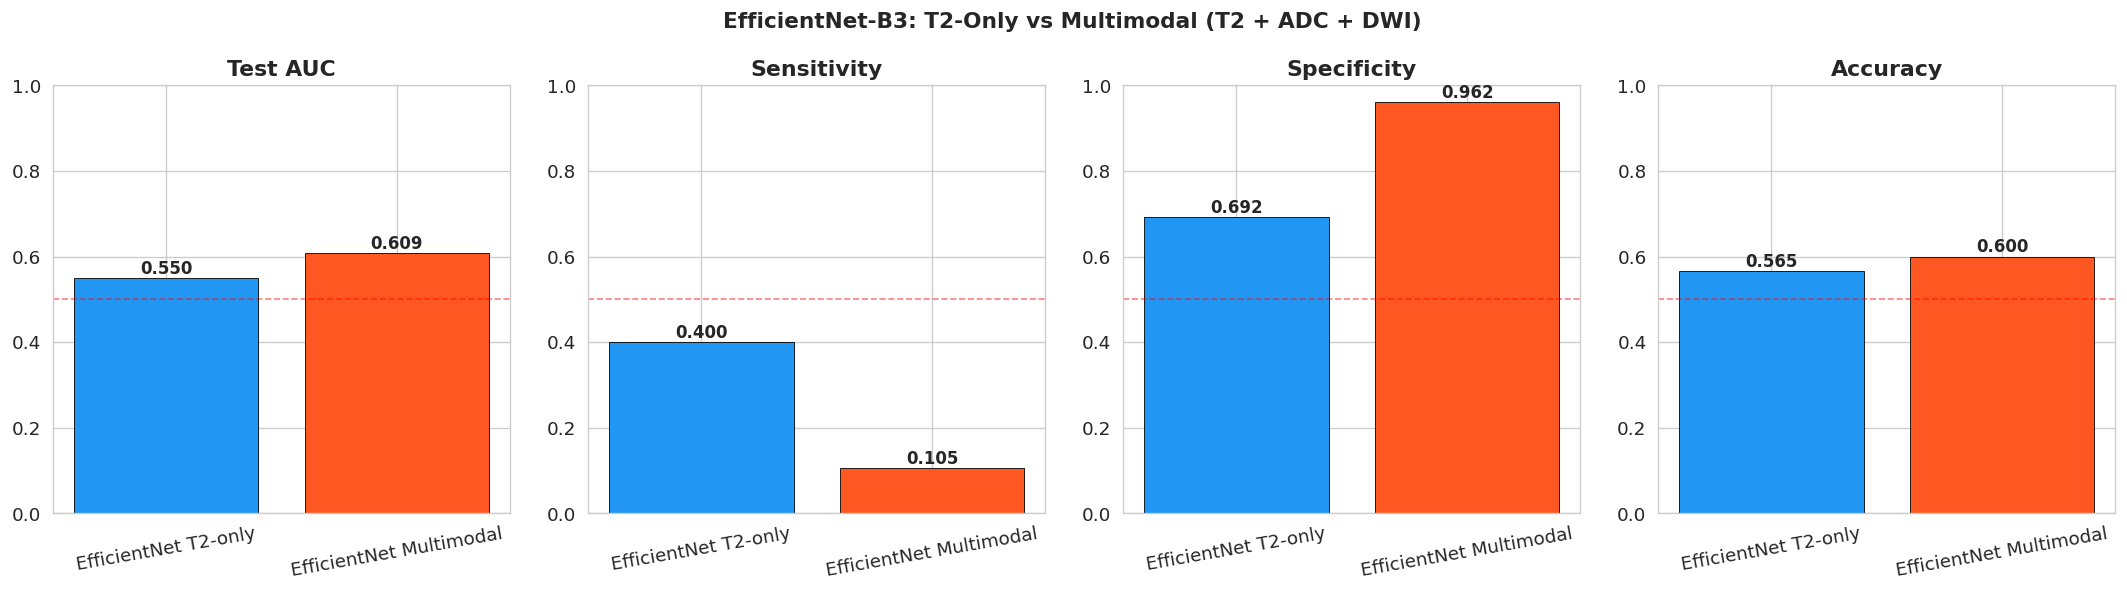

In [14]:
# Cell 14 — Bar chart comparison
metrics   = ['Test AUC', 'Sensitivity', 'Specificity', 'Accuracy']
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

model_names = [r['Model'] for r in summary_rows]
for ax, metric in zip(axes, metrics):
    vals = [summary_df.loc[summary_df['Model'] == n, metric].values[0] for n in model_names]
    bars = ax.bar(model_names, vals, color=colors[:len(model_names)],
                  edgecolor='black', linewidth=0.5)
    ax.set_title(metric, fontweight='bold')
    ax.set_ylim(0, 1.0)
    ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, linewidth=1)
    ax.tick_params(axis='x', rotation=10)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
               f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('EfficientNet-B3: T2-Only vs Multimodal (T2 + ADC + DWI)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/eval_eff_comparison.png', bbox_inches='tight')
plt.show()

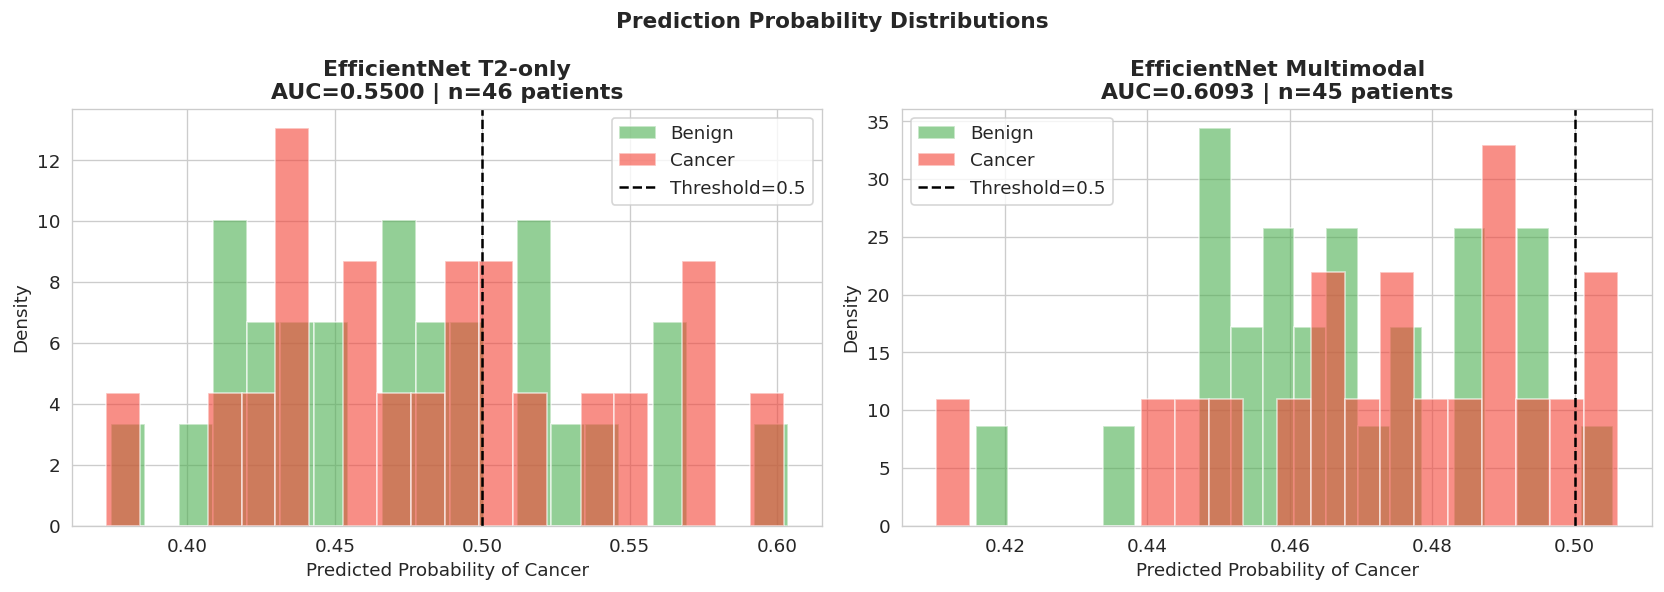

In [15]:
# Cell 15 — Probability distribution plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, data), color in zip(axes, model_predictions.items(), colors):
    benign_probs = data['probs'][data['labels'] == 0]
    cancer_probs = data['probs'][data['labels'] == 1]
    ax.hist(benign_probs, bins=20, alpha=0.6, color='#4CAF50', label='Benign', density=True)
    ax.hist(cancer_probs, bins=20, alpha=0.6, color='#F44336', label='Cancer', density=True)
    ax.axvline(x=0.5, color='black', linestyle='--', linewidth=1.5, label='Threshold=0.5')
    auc = roc_auc_score(data['labels'], data['probs'])
    ax.set_title(f'{name.replace(chr(10), " ")}\nAUC={auc:.4f} | n={len(data["labels"])} patients',
                fontweight='bold')
    ax.set_xlabel('Predicted Probability of Cancer')
    ax.set_ylabel('Density')
    ax.legend()

plt.suptitle('Prediction Probability Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/eval_eff_probs.png', bbox_inches='tight')
plt.show()

In [16]:
# Cell 16 — Final summary
print('=' * 65)
print('  EFFICIENTNET-B3: T2-ONLY vs MULTIMODAL (T2 + ADC + DWI)')
print('=' * 65)
print(f'  Dataset:  fastMRI Prostate, NYU (312 patients, T2 + DWI MRI)')
print(f'  Task:     Binary PIRADS classification (≥3 = cancer)')
print(f'  Tuning:   Optuna (10 trials, TPE + MedianPruner)')
print()
print(f'  {"Model":<30} {"N":>5} {"Val AUC":>10} {"Test AUC":>10} {"Sensitivity":>13} {"Specificity":>13}')
print('  ' + '-' * 75)
for _, row in summary_df.iterrows():
    key     = 'EfficientNet T2-only' if 'T2' in row['Model'] else 'EfficientNet Multimodal'
    val_auc = results.get(key, {}).get('best_val_auc', 'N/A')
    val_str = f'{val_auc:.4f}' if isinstance(val_auc, float) else val_auc
    print(f'  {row["Model"]:<30} {row["N patients"]:>5} {val_str:>10} '
          f'{row["Test AUC"]:>10.4f} {row["Sensitivity"]:>13.4f} {row["Specificity"]:>13.4f}')
print()
print('  Inputs:')
print('    T2-only:    AX_T2 only (3x3 grid, 3 channels)')
print('    Multimodal: AX_T2 + AX_DIFFUSION_ADC + AX_DIFFUSION_TRACEW + AX_DIFFUSION_CALC_BVAL')
print('                (3x3 grid per sequence, 4 channels stacked)')
print('=' * 65)

# AUC improvement
if len(summary_df) == 2:
    t2_auc = summary_df.iloc[0]['Test AUC']
    mm_auc = summary_df.iloc[1]['Test AUC']
    diff   = mm_auc - t2_auc
    direction = 'improvement' if diff > 0 else 'decrease'
    print(f'\n  DWI contribution: {abs(diff):.4f} AUC {direction} from adding multimodal input')

  EFFICIENTNET-B3: T2-ONLY vs MULTIMODAL (T2 + ADC + DWI)
  Dataset:  fastMRI Prostate, NYU (312 patients, T2 + DWI MRI)
  Task:     Binary PIRADS classification (≥3 = cancer)
  Tuning:   Optuna (10 trials, TPE + MedianPruner)

  Model                              N    Val AUC   Test AUC   Sensitivity   Specificity
  ---------------------------------------------------------------------------
  EfficientNet T2-only              46     0.6813     0.5500        0.4000        0.6923
  EfficientNet Multimodal           45     0.5861     0.6093        0.1053        0.9615

  Inputs:
    T2-only:    AX_T2 only (3x3 grid, 3 channels)
    Multimodal: AX_T2 + AX_DIFFUSION_ADC + AX_DIFFUSION_TRACEW + AX_DIFFUSION_CALC_BVAL
                (3x3 grid per sequence, 4 channels stacked)

  DWI contribution: 0.0593 AUC improvement from adding multimodal input
